57.625 32.0 50.875 51.625
데이터 [[59, 35]] , 판정 결과: 닥스훈트
[[1.44469259 1.97647298 1.98168619]] [[ 66  35 285]]
[[60.12111582 34.08882712]
 [60.93232719 35.41539989]
 [57.09602928 34.45047688]]


(np.float64(18.204008195544905),
 np.float64(83.23556623642479),
 np.float64(-4.2849142052352365),
 np.float64(88.99152630166266))

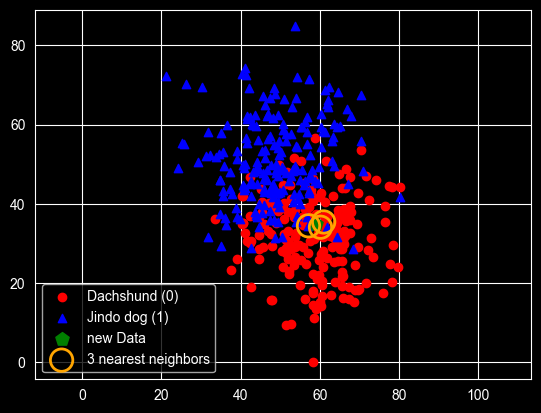

In [1]:
#ipynb

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

#로지스틱 회귀 모델
# 닥스훈트(클래스 0) 길이/높이 데이터 (각 8개)
dach_length = np.array([55, 57, 64, 63, 58, 49, 54, 61])
dach_height = np.array([30, 31, 36, 30, 33, 25, 37, 34])
jin_length  = np.array([56, 47, 56, 46, 49, 53, 52, 48])
jin_height  = np.array([52, 52, 50, 53, 50, 53, 49, 54])

a=dach_length.mean()
b=dach_height.mean()
c=jin_length.mean()
d=jin_height.mean()
print(a, b, c, d)

dach_length_random = np.random.randn(200) * 10 +57.625
dach_height_random =np.random.randn(200) * 10 +32.0
jin_length_random =np.random.randn(200) * 10 +50.875
jin_height_random =np.random.randn(200) * 10 +51.625
 #sklearn 입력은 (샘플수, 특성수) 2차원 형태 권장
newdata = np.array([[59, 35]]) #1행 2열


d_data = np.column_stack((dach_length_random, dach_height_random))
# 닥스훈트 샘플 8개, 특성(길이/높이) 2개
d_label = np.zeros(len(d_data), dtype=int)
# 0이 8개
j_data = np.column_stack((jin_length_random, jin_height_random))
j_label = np.ones(len(j_data), dtype=int)
dogs = np.concatenate((d_data, j_data), axis=0)
#(16,2)
labels = np.concatenate((d_label, j_label), axis=0)


dog_classes = {0: '닥스훈트', 1: '진돗개'} #0과 1로 딕셔너리로 만듬

k = 3

knn = KNeighborsClassifier(n_neighbors=k)
#knn 알고리즘 가장 가까운거 3개


knn.fit(dogs, labels)
#fit 함수로 모델 학습

y_pred = knn.predict(newdata)
#predict 분류결과 class 레이블 출력 레이블 class 번호
#print(y_pred[-1])


print('데이터', newdata.tolist(), ', 판정 결과:', dog_classes[int(y_pred[-1])])
#맨뒤 한개

distances, indices = knn.kneighbors(newdata, n_neighbors=k) #다중 반환(튜플 언패킹)
#차이: (59-58)=1, (35-33)=2
#: √(1²+2²)=√5=2.2360679..
#    - distances: 거리들
#    - indices: dogs에서의 행 인덱스들

print(distances, indices)
neighbor_pts = dogs[indices[0]] #0번째 행값 3개
# 0:(55,30)
# 1:(57,31)
# 2:(64,36)
# 3:(63,30)
# 4:(58,33)
# 5:(49,25)
# 6:(54,37)
# 7:(61,34)
print(neighbor_pts)

plt.scatter(dach_length_random, dach_height_random, c='r', label='Dachshund (0)')
plt.scatter(jin_length_random, jin_height_random, c='b', marker='^', label='Jindo dog (1)')

# 새 데이터 (초록색)
plt.scatter(newdata[0, 0], newdata[0, 1], s=100, marker='p', c='g', label='new Data')


plt.scatter(neighbor_pts[:, 0], neighbor_pts[:, 1], #0열 1열
             marker='o',facecolors='none', edgecolors='orange',
            s=260, linewidths=2, label=f'{k} nearest neighbors', zorder=10)
# neighbor_pts[:,0] = 이웃들의 길이들, neighbor_pts[:,1] = 이웃들의 높이들


plt.legend() #범례 설명박스
plt.axis('equal')#x,y 길이 맞춰줘

#plt.show()
